### Patch Antenna
We now apply a refined mesh for the patch antenna. Because the electromagnetic fields change rapidly near the metallic patch and the substrate edges, we increase the mesh density in these areas to ensure high simulation accuracy for resonance and radiation patterns.

In [1]:
import gmsh
import math
import os
import json

from palacetoolkit.simulation import generate_palace_config_from_entities
from palacetoolkit.viz import view_mesh, run_with_scrollable_output
from palacetoolkit.mesh import (
    Entity, 
    run_meshing_pipeline, 
    generate_3d_mesh, 
    refine_near_surfaces
)


### Parameters:
- l : Patch length along x-axis, specified as a scalar in meters.
- w : Patch width along y-axis, specified as a scalar in meters.
- h : Patch height along z-axis, specified as a scalar in meters. 
- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- l2 : Notch length along x-axis, specified as a scalar in meters. 
- w2 : Notch width along x-axis, specified as a scalar in meters. 
- w3 : Strip line width along y-axis, specified as a scalar in meters.
- air_height : Air box height along z-axis, specified as a scalar in meters.  
- air_margin : Air box margin along x and y axes, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.

In [2]:
l: float = 0.030
w: float = 0.029
l1: float = 0.06
w1: float = 0.06
l2: float = 0.008
w2: float = 0.003
w3: float = 0.001
h: float = 0.0013
air_height: float = 0.025    
air_margin: float = 0.025    
freq: float = 3.3
filename: str = "patch_antenna.msh"

# dielectric properties of the substrate
mu_r: float = 1.0
eps_r: float = 2.2
loss_tan: float = 0.0009

# lumped port impedance
port_impedance = 50.0

wavelength = wavelength = 3e8 / (freq * 1e9)

### Initialize the model

In [3]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ

### Geometry Construction
In this step, we build the physical structure of the patch antenna. We define the substrate, the metallic ground plane, and the antenna patch itself.

Patch Design: We combine the main patch and the feed line, including an inset to help with impedance matching.
Excitation: A lumped port is created and positioned to feed the antenna.
Domain Setup: We enclose the entire structure in an "air box," which defines the simulation region (the radiation space).
Finalizing: We use boolean operations (fragmenting) to ensure all components are properly connected and recognized as a single cohesive model by the solver.

In [4]:
# Total domain bounds
total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmax = h + air_height

# Substrate
substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)

# Ground plane
ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

# Patch definition
main_patch = kernel.addRectangle(-l/2, -w/2, h, l, w)
inset = kernel.addRectangle(-l/2, -w2/2, h, l2, w2)

patch_dimtags, _ = kernel.cut(
    [(2, main_patch)], 
    [(2, inset)], 
    removeObject=True, removeTool=True
)
kernel.synchronize()


feed_length = (l1 - l)/2 + l2
feed_line = kernel.addRectangle(-l1/2, -w3/2, h, feed_length, w3)

# Our patch
top_conductor, _ = kernel.fuse(
    patch_dimtags, [(2, feed_line)],
    removeObject=True, removeTool=True
)
kernel.synchronize()

# Gap bewteen the gropund plane and the bottom of the lumped port.
gap = 0
lumped_port = kernel.addRectangle(-l1/2 + gap, -w3/2, 0, h - gap, w3)
kernel.rotate([(2, lumped_port)], -l1/2, 0, 0, 0, 1, 0, -math.pi/2)
kernel.synchronize()

air_box = kernel.addBox(
    total_xmin, total_ymin, 0,
    total_xmax - total_xmin,
    total_ymax - total_ymin,
    total_zmax
)
kernel.synchronize()

Info    : Cannot bind existing OpenCASCADE surface 8 to second tag 9                                                      
Info    : Could not preserve tag of 2D object 9 (->8)


### Entities definition and mesh refinement.

In [ ]:
# Define the entities which later will become the physical groups.
entities = [
    Entity("air_box", dim = 3, mesh_order = 2, btype = "dielectric", tags = [air_box], loss_tan = 0.0, eps_r = 1.0, mu_r = 1.0),
    Entity("substrate", dim = 3, mesh_order = 1, btype = "dielectric", tags = [substrate], loss_tan = loss_tan, eps_r = eps_r, mu_r = mu_r),
    Entity("top_conductor", dim = 2, mesh_order= 1, btype = "pec", tags = [top_conductor[0][1]]),
    Entity("ground_plane", dim = 2, mesh_order = 1, btype = "pec", tags = [ground_plane]),
    Entity("lumped_port", dim = 2, mesh_order = 0, btype = "lumped_port", tags = [lumped_port], R = port_impedance, direction = '+Z', excitation = True)
]

# Boolean operations to guarantee a nice mesh, algo it returns the
# physical group map.
pg_map = run_meshing_pipeline(entities)

# Refine near the top conductor and locally the lumped port
refine_near_surfaces(entities[2].dimtags, 
                     wavelength, 
                     ppw_near=50, 
                     ppw_far=30, 
                     set_as_background=True,
                     local_refinements = {entities[-1].dimtags[0]: 150})

# Mesh sizes
mesh_sizes = {
    "substrate": wavelength / 12,
    "air_box": wavelength / 4,
    "lumped_port": wavelength / 150,
    "ground_plane" : wavelength / 10,
    "top_conductor": wavelength / 50
}

def _generate_patch_mesh():
    generate_3d_mesh(entities, mesh_sizes, filename, optimize=True)
    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.write(filename)

run_with_scrollable_output(_generate_patch_mesh, title = "Patch antenna mesh generation", max_lines=10)
gmsh.finalize()

  Physical group 'air_box' (dim=3): pg=1, tags=[2]                                                                                               
  Physical group 'substrate' (dim=3): pg=2, tags=[1]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[8]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[7]
  Physical group 'lumped_port' (dim=2): pg=5, tags=[9]
  Physical group 'air_box__None' (dim=2): pg=6, tags=[16, 17, 18, 19, 20, 21]
  Physical group 'air_box__substrate' (dim=2): pg=7, tags=[10, 11, 13, 12, 14, 15]
  ppw_near=50  ppw_far=30
  SizeMax=0.0030  transition=0.0227
  global: 12 curves, SizeMin=0.0018
  local (2, 9): 4 curves, SizeMin=0.0006
  Merged 2 fields with Min → field 5


Mesh saved to patch_antenna.msh
  Nodes: 15345
  Elements: 88452


### Mesh visualization

Loading mesh file: patch_antenna.msh
Groups to render transparent: air_box__None

Mesh loaded successfully with 2 cell blocks
Found 13667 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port', 6: 'air_box__None', 7: 'air_box__substrate'}


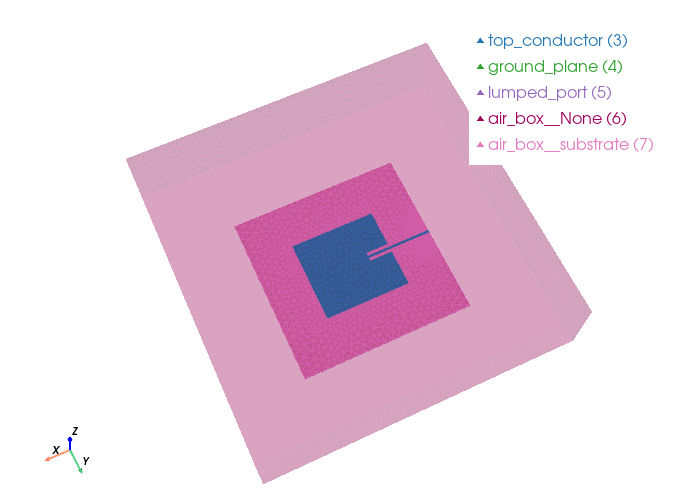

In [6]:
view_mesh(filename, transparent_groups= "air_box__None")

### Simulation Configuration
We define the key parameters for the electromagnetic simulation here. These settings control the frequency sweep range, material properties (dielectric constant and loss tangent for the substrate), and solver-specific configurations like port impedance and mesh order.

- output_file  : output filename for the configuration JSON file
- freq_min : minimum frequency for the simulation (GHz)  
- freq_max: maximum frequency for the simulation (GHz)
- freq_step: frequency step for the simulation (GHz)
- eps_r: relative permittivity of the substrate
- loss_tan: loss tangent of the substrate
- port_impedance: characteristic impedance of the lumped port (Ohms)
- solver_order: order of the finite element basis functions for the simulation (e.g., 1 for linear, 2 for quadratic)

In [7]:
output_file: str = "patch_antenna.json"
freq_min: float = 3.0
freq_max: float = 3.5
freq_step: float = 0.005
solver_order: int = 2

### Generating the Palace Configuration File
Finally, we assemble the simulation parameters into a JSON configuration .

In [8]:
generate_palace_config_from_entities(entity_defs = [e.to_dict() for e in entities],
    pg_map = pg_map,
    mesh_file = filename,
    output_file = 'patch.config',
    freq_min = freq_min,
    freq_max = freq_max,
    freq_step = freq_step ,
    L0 = 1.0,
    solver_order = solver_order,
    absorbing_order = 2)

Palace config written to patch.config


{'Problem': {'Type': 'Driven', 'Verbose': 2, 'Output': 'postpro/patch'},
 'Model': {'Mesh': 'patch_antenna.msh', 'L0': 1.0, 'Refinement': {}},
 'Domains': {'Materials': [{'Attributes': [1],
    'Permeability': 1.0,
    'Permittivity': 1.0,
    'LossTan': 0.0},
   {'Attributes': [2],
    'Permeability': 1.0,
    'Permittivity': 2.2,
    'LossTan': 0.0009}]},
 'Boundaries': {'PEC': {'Attributes': [3, 4]},
  'Absorbing': {'Attributes': [6, 7], 'Order': 2},
  'LumpedPort': [{'Index': 1,
    'Attributes': [5],
    'R': 50.0,
    'Excitation': True,
    'Direction': '+Z'}]},
 'Solver': {'Order': 2,
  'Device': 'CPU',
  'Driven': {'MinFreq': 3.0,
   'MaxFreq': 3.5,
   'FreqStep': 0.005,
   'SaveStep': 5,
   'AdaptiveTol': 0.001},
  'Linear': {'Type': 'Default',
   'KSPType': 'GMRES',
   'Tol': 1e-08,
   'MaxIts': 500}}}